# Hierarchical Clustering: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Hierarchical Clustering** in Python.

### Concept Overview
Constructs tree-like structures (dendrograms) by iteratively grouping (agglomerative) or splitting (divisive) data clusters.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
\text{Ward's Linkage: } \Delta(A, B) = \frac{n_A n_B}{n_A + n_B} \|\boldsymbol{\mu}_A - \boldsymbol{\mu}_B\|^2
$$

### Real-World Analogy
**Analogy:** Structuring file systems recursively into sub-folders, folders, and parent directories.

### Worked Example
**Worked Example:** Grouping delivery store sites. Agglomerative clustering starts with each site as its own cluster. It merges the two closest sites, repeating until all merge into one grand tree.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of geographical retail spots
from sklearn.datasets import make_blobs
np.random.seed(42)
X_raw, _ = make_blobs(n_samples=300, n_features=2, centers=4, cluster_std=1.0, random_state=42)
df = pd.DataFrame({
    'LatitudeOffset': np.round(X_raw[:, 0] * 3, 4),
    'LongitudeOffset': np.round(X_raw[:, 1] * 3, 4)
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (300, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   LatitudeOffset   300 non-null    float64
 1   LongitudeOffset  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB
       LatitudeOffset  LongitudeOffset
count      300.000000       300.000000
mean       -10.211511         8.535985
std         15.867462        18.677226
min        -33.929900       -26.758000
25%        -23.856675        -3.543400
50%        -14.124400        15.201000
75%         -0.352800        24.238300
max         20.863600        34.432600


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 LatitudeOffset     0
LongitudeOffset    0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

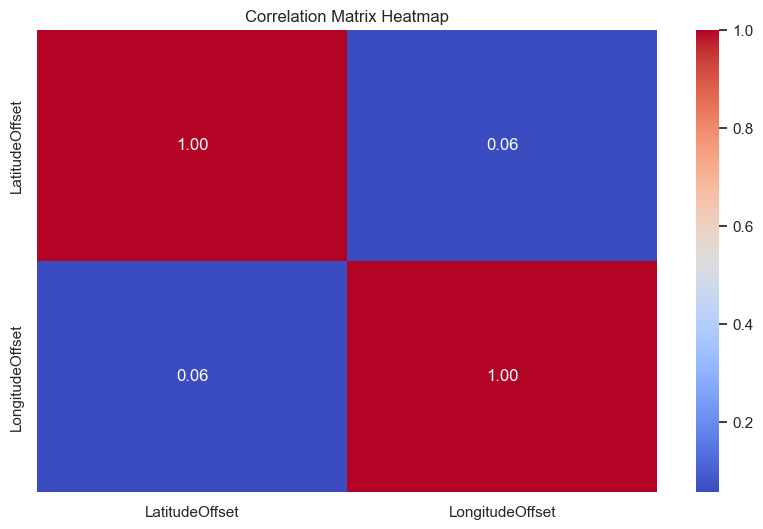

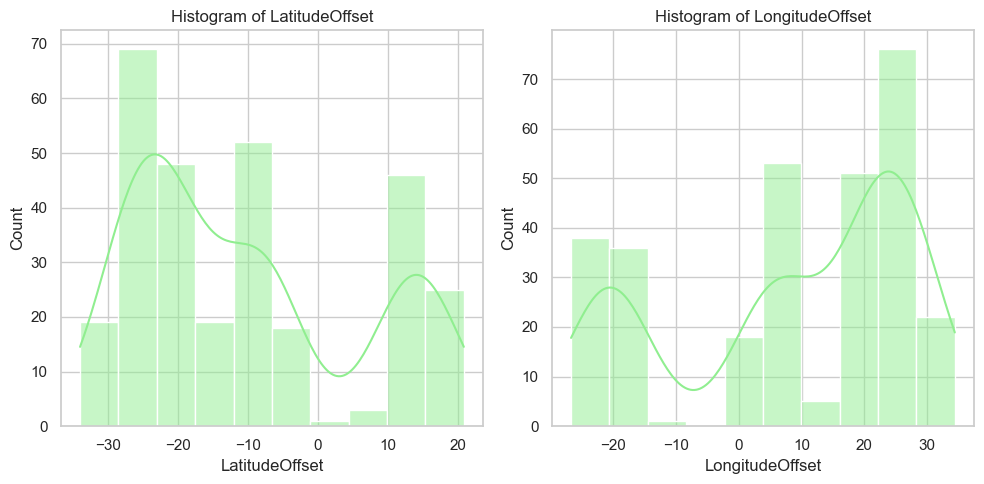

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Histograms of features
fig, axes = plt.subplots(1, len(df.columns), figsize=(5 * len(df.columns), 5))
if len(df.columns) == 1:
    sns.histplot(df.iloc[:, 0], kde=True, ax=axes, color='lightgreen')
    axes.set_title(f'Histogram of {df.columns[0]}')
else:
    for idx, col in enumerate(df.columns):
        sns.histplot(df[col], kde=True, ax=axes[idx], color='lightgreen')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Standard scaling applied.')

Standard scaling applied.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
# Unsupervised model - fitting directly on the scaled cohort
print('Skipping split step.')

Skipping split step.


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = AgglomerativeClustering(n_clusters=4, linkage='ward')
model.fit(X_scaled)
print("Agglomerative model fitted.")

Agglomerative model fitted.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
labels = model.labels_
# Guard: silhouette_score requires at least 2 distinct non-noise labels
unique_labels = set(labels)
if len(unique_labels - {-1}) >= 2:
    mask = labels != -1
    print('Silhouette Score:', silhouette_score(X_scaled[mask], labels[mask]))
else:
    print('Silhouette Score: N/A')

Silhouette Score: 0.7974738432253633


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

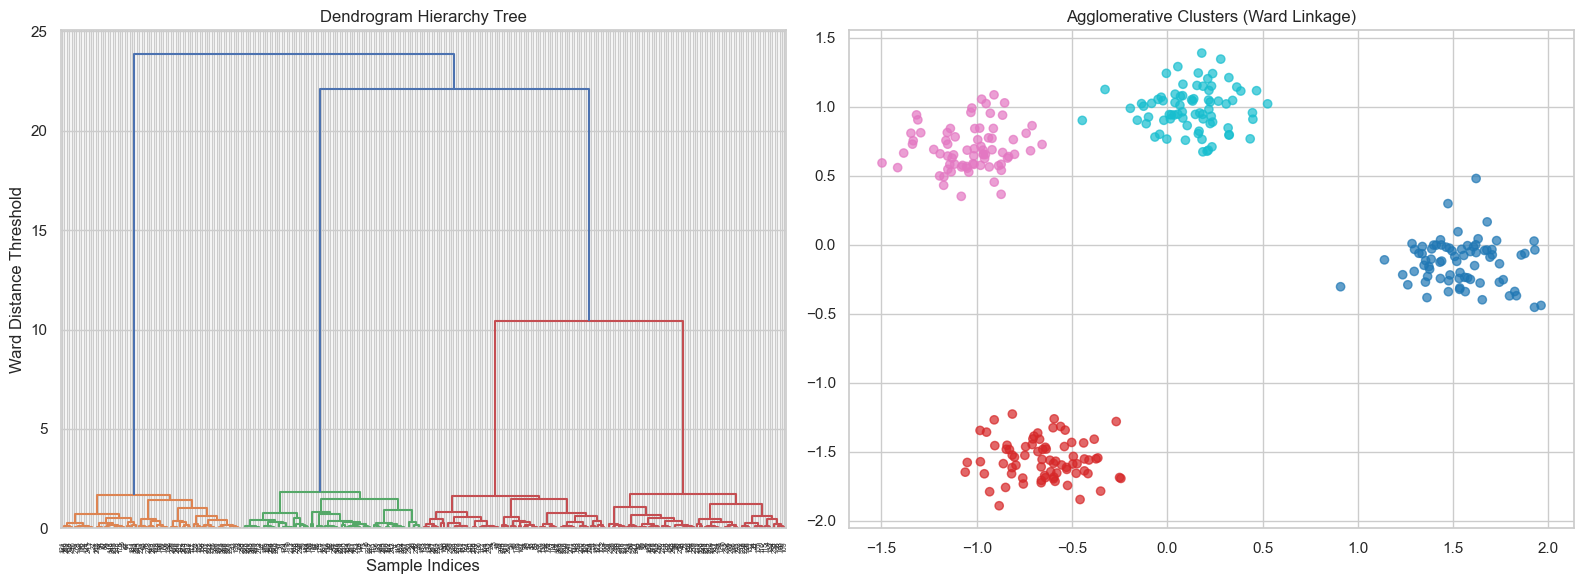

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot 1: Dendrogram
import scipy.cluster.hierarchy as sch
sch.dendrogram(sch.linkage(X_scaled, method='ward'), ax=axes[0])
axes[0].set_title("Dendrogram Hierarchy Tree")
axes[0].set_xlabel("Sample Indices")
axes[0].set_ylabel("Ward Distance Threshold")

# Plot 2: Agglomerative Scatter
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_, cmap='tab10', alpha=0.7)
axes[1].set_title("Agglomerative Clusters (Ward Linkage)")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What is the difference between Agglomerative and Divisive clustering?**

*A: Agglomerative is a bottom-up approach (starts with individual points and merges them). Divisive is top-down (starts with one cluster and recursively splits it).*

**Q2: What are the common linkage criteria?**

*A: 1. Single (min distance between points). 2. Complete (max distance). 3. Average (mean distance). 4. Ward (minimizes variance within clusters).*

**Q3: How does a dendrogram determine the number of clusters?**

*A: By drawing a horizontal line across the dendrogram at a threshold height that does not intersect any vertical merge branches.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What is linkage method 'ward'?**

*A: An approach that minimizes the total within-cluster variance when merging two clusters.*

**Q2: Does Hierarchical Clustering require random seed initialization?**

*A: No, unlike KMeans, it is deterministic and does not rely on random seed initializations.*

**Q3: Name the library used for plotting the dendrogram tree.**

*A: `scipy.cluster.hierarchy`.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.